# PHYT1D — File 2: Patient Data, MCMC Identification & 24h Trajectory

**Run File 1 first:** `%run phyt1d_functions.ipynb`

**Contents:**
1. Patient CSV import
2. Fixed + user parameters
3. Ground-truth from patient CGM
4. MCMC Window A — identify θ_A
5. MCMC Window B — identify θ_B
6. Ensemble simulation (rest — no exercise)
7. Evaluation metrics
8. 24h glucose plot with uncertainty bands


In [13]:
# ── Import all functions from File 1 ─────────────────────────────────────────
%run phyt1d_functions_real.ipynb

# ── Import evaluation metric functions from Module 08 ────────────────────────
%run 08_evaluation_metrics.ipynb


PHYT1D Functions Library — v2.0
✓ estimate_VO2max defined
✓ FIXED parameters (Group D) loaded
✓ build_rates defined
✓ simulate_trajectory_main defined (multi-session)
✓ log_prior_A_main defined
✓ log_likelihood_main defined
✓ run_MCMC_A_main defined
✓ log_prior_B_main defined
✓ run_MCMC_B_main defined
✓ draw_posterior_samples defined
✓ run_ensemble defined
✓ MARD_fn, RMSE_fn, TIR_fn, print_eval_report defined

✓ ALL PHYT1D FUNCTIONS LOADED SUCCESSFULLY
  Import into other notebooks with:  %run phyt1d_functions.ipynb


## Step 0 — Patient CSV Import

In [14]:
import pandas as pd

# UoM_2301 10/11/2023 7:00 AM to 11/11/2023 7:00 AM

# ════════════════════════════════════════════════════
# ← CHANGE THIS PATH TO YOUR patient_data.csv FILE
CSV_PATH = r"C:\MY_PROJECTS\Exe_aware_DT\Virtual_Data_1_day\files (2)\UoM_2301_csv.csv"
# ════════════════════════════════════════════════════

df = pd.read_csv(CSV_PATH)

required_cols = {"time_min", "cgm_mgdl", "insulin_U", "cho_g"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"CSV missing columns: {missing}")

df = df.sort_values("time_min").reset_index(drop=True).fillna(0.0)

cgm_times = df["time_min"].values.astype(float)
cgm_obs   = df["cgm_mgdl"].values.astype(float)
insulin_U = df["insulin_U"].values.astype(float)
cho_g     = df["cho_g"].values.astype(float)

# Gb from fasting window (first 60 min, no meal, no bolus)
fasting_mask = (cgm_times <= 60) & (cho_g == 0) & (insulin_U == 0)
Gb_data = float(np.median(cgm_obs[fasting_mask]))           if fasting_mask.sum() > 3 else 120.0

bolus_mask  = insulin_U > 0.5
bolus_total = insulin_U[bolus_mask].sum()
basal_total = insulin_U[~bolus_mask].sum()

print(f"✓ Patient CSV loaded: {len(df)} rows")
print(f"  Time range  : {cgm_times[0]:.0f}–{cgm_times[-1]:.0f} min")
print(f"  CGM range   : {cgm_obs.min():.1f}–{cgm_obs.max():.1f} mg/dL")
print(f"  Gb (fasting): {Gb_data:.1f} mg/dL")
print(f"  Total bolus : {bolus_total:.2f} U")
print(f"  Total meals : {cho_g.sum():.0f} g CHO")

✓ Patient CSV loaded: 289 rows
  Time range  : 0–1440 min
  CGM range   : 84.6–250.2 mg/dL
  Gb (fasting): 123.3 mg/dL
  Total bolus : 8.81 U
  Total meals : 210 g CHO


## Step 1 — User Parameters (Group C)

In [15]:
def default_user_params():
    return {
        # Exercise — set u=0, d=0 for rest patient
        "u": 0.0, "d": 0.0, "t_start": 420.0, "exercise_type": "aerobic",
        # Insulin
        "CR": 15.0,
        # Meals (defaults — overridden from CSV below)
        "CHO_BF": 3.0, "CHO_LU": 101.0, "CHO_DN": 86.0, "CHO_SN": 20.0,
        "t_BF": 60.0, "t_LU": 343.0, "t_DN": 770.0, "t_SN": 800.0,
        # Modulation factors (nominal = 1.0)
        "bolus_factor": 1.0, "CHO_factor": 1.0,
        # Demographics
        "sex": "M", "age_group": "adult",
        # Basal insulin rate (U/h) — continuous background
        "basal_rate": 0.35,
    }

USER_PARAMS = default_user_params()
print("✓ Default Group C parameters loaded")


✓ Default Group C parameters loaded


## Step 1b — Load Exercise Sessions from Activity CSV

Reads the activity CSV, restricts to the 24h day matching this patient's CGM file, computes `duration = duration_s/60` (min) and `VO2max% = met × 3.5` for each row, filters out sedentary entries, then merges consecutive 15-min slots into exercise sessions.

In [16]:
# ════════════════════════════════════════════════════
# ← CHANGE THIS PATH TO YOUR activity CSV FILE
ACTIVITY_CSV = r"C:\MY_PROJECTS\T1D_TFT_DT\15806142\sharpic\ManchesterCSCoordinatedDiabetesStudy-V1.0.3\sharpic-ManchesterCSCoordinatedDiabetesStudy-fdbd74f\Activity Data\UoMActivity2301.csv"
# 24h simulation window (must match the CGM file)
DAY_START = pd.Timestamp("2023-11-10 07:00")
DAY_END   = pd.Timestamp("2023-11-11 07:00")
# ════════════════════════════════════════════════════

act = pd.read_csv(ACTIVITY_CSV)
act["activity_ts"] = pd.to_datetime(act["activity_ts"], format="%d/%m/%Y %H:%M")

# ── Restrict to 24h window and active rows (MET > 1) ─────────────────────
win = act[(act["activity_ts"] >= DAY_START) & (act["activity_ts"] < DAY_END)].copy()
win = win[win["met"] > 1.0].copy()
win["t_min"]      = ((win["activity_ts"] - DAY_START).dt.total_seconds() / 60).astype(int)
win["vo2_pct"]    = win["met"] * 3.5                       # %VO2max
win["duration_m"] = win["duration_s"] / 60.0                # minutes
win = win.sort_values("t_min").reset_index(drop=True)

# ── Merge consecutive 15-min slots into exercise sessions ────────────────
EXERCISE_SESSIONS = []                              # list of dicts for the simulator
cur = None
for _, row in win.iterrows():
    t_s = int(row["t_min"])
    dur = float(row["duration_m"])
    v   = float(row["vo2_pct"])
    if cur is None or t_s != cur["_end_tmp"]:       # gap → new session
        if cur is not None:
            EXERCISE_SESSIONS.append({
                "t_start": float(cur["_t_start"]),
                "d":       float(cur["_end_tmp"] - cur["_t_start"]),
                "u":       float(np.mean(cur["_vs"])),    # mean %VO2max
                "exercise_type": "aerobic",
            })
        cur = {"_t_start": t_s, "_end_tmp": t_s + dur, "_vs": [v]}
    else:                                            # extends current session
        cur["_end_tmp"] += dur
        cur["_vs"].append(v)
if cur is not None:
    EXERCISE_SESSIONS.append({
        "t_start": float(cur["_t_start"]),
        "d":       float(cur["_end_tmp"] - cur["_t_start"]),
        "u":       float(np.mean(cur["_vs"])),
        "exercise_type": "aerobic",
    })

# ── Push sessions into USER_PARAMS ───────────────────────────────────────
USER_PARAMS["exercise_sessions"] = EXERCISE_SESSIONS
# Keep single-bout fields populated with the longest session (used by
# MCMC Window B which expects a scalar t_start / d for the fit window)
if EXERCISE_SESSIONS:
    longest = max(EXERCISE_SESSIONS, key=lambda s: s["d"])
    USER_PARAMS["u"]       = longest["u"]
    USER_PARAMS["d"]       = longest["d"]
    USER_PARAMS["t_start"] = longest["t_start"]

print(f"✓ {len(EXERCISE_SESSIONS)} exercise session(s) loaded from CSV")
print(f"  Window: {DAY_START}  →  {DAY_END}")
total_dur = sum(s["d"] for s in EXERCISE_SESSIONS)
mean_int  = (np.mean([s["u"] for s in EXERCISE_SESSIONS])
             if EXERCISE_SESSIONS else 0.0)
print(f"  Total active time: {total_dur:.0f} min   mean intensity: {mean_int:.2f} %VO2max")
for i, s in enumerate(EXERCISE_SESSIONS, 1):
    print(f"  [{i:2d}] t={s['t_start']:6.1f}–{s['t_start']+s['d']:6.1f} min   "
          f"d={s['d']:5.1f} min   u={s['u']:5.2f} %VO2max")


✓ 15 exercise session(s) loaded from CSV
  Window: 2023-11-10 07:00:00  →  2023-11-11 07:00:00
  Total active time: 405 min   mean intensity: 8.32 %VO2max
  [ 1] t=  30.0–  45.0 min   d= 15.0 min   u= 6.58 %VO2max
  [ 2] t=  75.0– 135.0 min   d= 60.0 min   u=11.16 %VO2max
  [ 3] t= 225.0– 240.0 min   d= 15.0 min   u= 3.91 %VO2max
  [ 4] t= 330.0– 360.0 min   d= 30.0 min   u= 7.03 %VO2max
  [ 5] t= 390.0– 405.0 min   d= 15.0 min   u= 8.78 %VO2max
  [ 6] t= 570.0– 600.0 min   d= 30.0 min   u=11.40 %VO2max
  [ 7] t= 615.0– 630.0 min   d= 15.0 min   u= 9.66 %VO2max
  [ 8] t= 615.0– 630.0 min   d= 15.0 min   u= 4.01 %VO2max
  [ 9] t= 660.0– 750.0 min   d= 90.0 min   u=10.25 %VO2max
  [10] t= 765.0– 780.0 min   d= 15.0 min   u= 6.58 %VO2max
  [11] t= 810.0– 825.0 min   d= 15.0 min   u= 9.66 %VO2max
  [12] t= 885.0– 930.0 min   d= 45.0 min   u= 9.92 %VO2max
  [13] t=1005.0–1020.0 min   d= 15.0 min   u= 6.58 %VO2max
  [14] t=1080.0–1095.0 min   d= 15.0 min   u= 9.66 %VO2max
  [15] t=1335.0–135

## Step 2 — VO2max Prior

In [17]:
vo2_prior_mean = estimate_VO2max(USER_PARAMS["age_group"], USER_PARAMS["sex"])
vo2_prior_std  = 8.0
print(f"✓ VO2max prior: N({vo2_prior_mean:.1f}, {vo2_prior_std}²) mL/kg/min")


✓ VO2max prior: N(45.2, 8.0²) mL/kg/min


## Step 3 — Build Ground-Truth and USER_PARAMS from CSV

In [18]:
# Interpolate patient CGM onto uniform 5-min simulation grid
times_true = np.arange(0, 1441, 5, dtype=float)
ig_true    = np.interp(times_true, cgm_times, cgm_obs)
times_h    = times_true / 60

# Detect meals chronologically from CSV
meal_events = sorted(
    [(cgm_times[i], cho_g[i]) for i in range(len(cgm_times)) if cho_g[i] > 5.0],
    key=lambda x: x[0]
)
slot_names = ["BF", "LU", "DN", "SN"]
meal_slots = {"BF":(60,3.), "LU":(343,101.), "DN":(770,86.), "SN":(800,20.)}
for i, (t_meal, cho) in enumerate(meal_events[:4]):
    meal_slots[slot_names[i]] = (t_meal, cho)

# Estimate CR from largest meal-bolus pair
bolus_events = [(cgm_times[i], insulin_U[i])
                for i in range(len(cgm_times)) if insulin_U[i] > 0.5]
CR_data = 15.0
if bolus_events and meal_events:
    lm_t, lm_cho = max(meal_events, key=lambda x: x[1])
    cb = min(bolus_events, key=lambda b: abs(b[0] - lm_t))
    if cb[1] > 0:
        CR_data = float(np.clip(round(lm_cho / cb[1], 1), 5.0, 30.0))

USER_PARAMS.update({
    "CR"    : CR_data,
    "CHO_BF": meal_slots["BF"][1], "t_BF": meal_slots["BF"][0],
    "CHO_LU": meal_slots["LU"][1], "t_LU": meal_slots["LU"][0],
    "CHO_DN": meal_slots["DN"][1], "t_DN": meal_slots["DN"][0],
    "CHO_SN": meal_slots["SN"][1], "t_SN": meal_slots["SN"][0],
    "Gb"    : Gb_data,
})

# Initial parameter values
THETA_A_TRUE = {
    "SI": np.exp(-5.3), "SG": 0.025, "Gb": Gb_data,
    "p2": 0.025, "kd": 0.026, "ka2": 0.066,
    "kempt": 0.055, "kabs": 0.057,
}
THETA_B_TRUE = {
    "beta_aer": 0.50, "beta_res": 0.30, "tau_post": 240.0,
    "tau_on": 15.0, "VO2max": vo2_prior_mean, "phi": 0.1,
}
THETA_A_TRUE["Gb"] = Gb_data

print(f"✓ Patient data prepared")
print(f"  Gb={Gb_data:.1f} mg/dL   CR={CR_data:.1f} g/U")
print(f"  Meals:")
for slot, (t, cho) in meal_slots.items():
    print(f"    {slot}: {cho:.0f}g at t={t:.0f} min ({t/60:.1f}h)")
print(f"  IG trace: {len(ig_true)} pts  "
      f"mean={ig_true.mean():.1f}  "
      f"TIR={np.sum((ig_true>=70)&(ig_true<=180))/len(ig_true)*100:.1f}%")


✓ Patient data prepared
  Gb=123.3 mg/dL   CR=30.0 g/U
  Meals:
    BF: 101g at t=340 min (5.7h)
    LU: 15g at t=760 min (12.7h)
    DN: 71g at t=770 min (12.8h)
    SN: 20g at t=810 min (13.5h)
  IG trace: 289 pts  mean=146.3  TIR=76.1%


## Step 4 — MCMC Window A: Identify θ_A

In [19]:
# Window A: full day, excluding 15-min bolus spikes around each meal
meal_times = [USER_PARAMS["t_BF"], USER_PARAMS["t_LU"],
              USER_PARAMS["t_DN"], USER_PARAMS["t_SN"]]
spike_mask = np.zeros(len(times_true), dtype=bool)
for tm in meal_times:
    spike_mask |= (times_true >= tm) & (times_true <= tm + 15)

win_A_mask = ~spike_mask
cgm_wA     = ig_true[win_A_mask]
times_wA   = times_true[win_A_mask]
user_noex  = USER_PARAMS.copy(); user_noex["u"] = 0.0  # no exercise for Window A

print(f"Window A: {win_A_mask.sum()} CGM points across full day")

THETA_A_INIT = {"SI": np.exp(-5.3), "SG": 0.025, "Gb": Gb_data,
                "p2": 0.025, "kd": 0.026, "ka2": 0.066,
                "kempt": 0.055, "kabs": 0.057}
THETA_B_INIT = {"beta_aer": 0.50, "beta_res": 0.30, "tau_post": 240.0,
                "tau_on": 15.0, "VO2max": vo2_prior_mean, "phi": 0.1}

print("\nRunning MCMC Window A (2000 iterations)...")
chain_A = run_MCMC_A_main(THETA_A_INIT, THETA_B_INIT, cgm_wA, times_wA,
                           user_noex, FIXED, n_samples=2000, burn_in=1000)
THETA_A_MED = {k: np.median([s[k] for s in chain_A]) for k in chain_A[0]}

print("\n✓ Window A complete. Posterior medians:")
for k, v in THETA_A_MED.items():
    true_v = THETA_A_TRUE[k]
    re = abs(v - true_v) / abs(true_v) * 100
    print(f"  {k:8s}  est={v:.5f}  init={true_v:.5f}  RE={re:.1f}%")

Window A: 275 CGM points across full day

Running MCMC Window A (2000 iterations)...
  Window A    200/2000  accept=0.27  lp=-2623.8
  Window A    400/2000  accept=0.16  lp=-2526.8
  Window A    600/2000  accept=0.13  lp=-2459.3
  Window A    800/2000  accept=0.11  lp=-2418.5
  Window A   1000/2000  accept=0.11  lp=-2404.2
  Window A   1200/2000  accept=0.12  lp=-2382.7
  Window A   1400/2000  accept=0.12  lp=-2375.8
  Window A   1600/2000  accept=0.12  lp=-2358.5
  Window A   1800/2000  accept=0.12  lp=-2354.3
  Window A   2000/2000  accept=0.12  lp=-2353.7


✓ Window A complete. Posterior medians:
  SI        est=0.00018  init=0.00499  RE=96.4%
  SG        est=0.00983  init=0.02500  RE=60.7%
  Gb        est=150.63270  init=123.30000  RE=22.2%
  p2        est=0.00256  init=0.02500  RE=89.8%
  kd        est=0.00050  init=0.02600  RE=98.1%
  ka2       est=0.00270  init=0.06600  RE=95.9%
  kempt     est=0.00372  init=0.05500  RE=93.2%
  kabs      est=0.01900  init=0.05700  RE=66.7%


## Step 5 — MCMC Window B: Identify θ_B

In [20]:
# Window B: exercise window + 6h post (or post-lunch if no exercise)
t_ex       = USER_PARAMS["t_start"]
win_B_mask = (times_true >= t_ex) & (times_true <= t_ex + 360.0)
cgm_wB     = ig_true[win_B_mask]
times_wB   = times_true[win_B_mask]
print(f"Window B: {win_B_mask.sum()} CGM points  "
      f"(t={t_ex:.0f}–{t_ex+360:.0f} min)")

print("Running MCMC Window B (2000 iterations)...")
chain_B = run_MCMC_B_main(THETA_B_INIT, THETA_A_MED, cgm_wB, times_wB,
                           USER_PARAMS, FIXED, vo2_mean=vo2_prior_mean,
                           n_samples=2000, burn_in=1000)

THETA_B_MED = {k: np.median([s[k] for s in chain_B]) for k in chain_B[0]}
print("\n✓ Window B complete. Posterior medians:")
for k, v in THETA_B_MED.items():
    true_v = THETA_B_TRUE[k]
    re = abs(v - true_v) / abs(true_v) * 100
    print(f"  {k:10s}  est={v:.4f}  init={true_v:.4f}  RE={re:.1f}%")


Window B: 73 CGM points  (t=660–1020 min)
Running MCMC Window B (2000 iterations)...
  Window B    200/2000  accept=0.53
  Window B    400/2000  accept=0.53
  Window B    600/2000  accept=0.53
  Window B    800/2000  accept=0.51
  Window B   1000/2000  accept=0.50
  Window B   1200/2000  accept=0.48
  Window B   1400/2000  accept=0.46
  Window B   1600/2000  accept=0.46
  Window B   1800/2000  accept=0.45
  Window B   2000/2000  accept=0.44


✓ Window B complete. Posterior medians:
  beta_aer    est=0.2548  init=0.5000  RE=49.0%
  beta_res    est=0.2998  init=0.3000  RE=0.1%
  tau_post    est=1410.3278  init=240.0000  RE=487.6%
  tau_on      est=18.7329  init=15.0000  RE=24.9%
  VO2max      est=43.4689  init=45.1930  RE=3.8%
  phi         est=0.1102  init=0.1000  RE=10.2%


## Step 6 — Ensemble Simulation (with logged exercise sessions)

In [21]:
# Ensemble simulation — USER_PARAMS now carries the full list of
# exercise sessions loaded from the activity CSV.  The simulator iterates
# all sessions internally, so a single run captures the cumulative glucose
# drop from every walking bout.
n_sess = len(USER_PARAMS.get("exercise_sessions", []))
print(f"Running ensemble with {n_sess} exercise session(s)...")

times_sim, IG_50, IG_25, IG_75, all_IG = run_ensemble(
    chain_A, chain_B, USER_PARAMS, FIXED, n_real=200)

times_h = times_true / 60   # hours for plotting


Running ensemble with 15 exercise session(s)...
Running 200 posterior realisations...
  50/200
  100/200
  150/200
  200/200
✓ 200/200 realisations valid.


## Step 7 — Evaluation Metrics

In [22]:
# ── Evaluation Metrics ───────────────────────────────────────────────────────
# All metric functions are imported from 08_evaluation_metrics.ipynb.
# IG_50 from run_ensemble() is already on the same 5-min grid as ig_true.

# ── MARD (Mean Absolute Relative Difference) — Module 8.1 ───────────────────
mard = MARD(ig_true, IG_50)

# ── gRMSE (Del Favero glucose-specific RMSE) — Module 8.2 ───────────────────
grmse = gRMSE(ig_true, IG_50)

# ── TIR / TBR / TAR (Battelino 2019) — Module 8.3 ───────────────────────────
tir_dict = time_in_range(ig_true, dt=5.0)   # 5-min sampling grid
tir = tir_dict['TIR']
tbr = tir_dict['TBR']
tar = tir_dict['TAR']

# ── Summary print ────────────────────────────────────────────────────────────
print("\n" + "═" * 52)
print("  EVALUATION METRICS")
print("═" * 52)
print(f"  MARD   : {mard:>8.2f} %       (target < 10 %)")
print(f"  gRMSE  : {grmse:>8.2f} mg/dL  (Del Favero 2012, risk-weighted)")
print("─" * 52)
print(f"  TIR    : {tir:>8.1f} %       (target ≥ 70 %)")
print(f"  TBR    : {tbr:>8.1f} %       (target < 4 %)")
print(f"  TAR    : {tar:>8.1f} %")
print("═" * 52)

# Store for use in Step 8 plot
metrics = dict(MARD=mard, gRMSE=grmse, TIR=tir, TBR=tbr, TAR=tar)



════════════════════════════════════════════════════
  EVALUATION METRICS
════════════════════════════════════════════════════
  MARD   :    12.79 %       (target < 10 %)
  gRMSE  :    22.68 mg/dL  (Del Favero 2012, risk-weighted)
────────────────────────────────────────────────────
  TIR    :     76.1 %       (target ≥ 70 %)
  TBR    :      0.0 %       (target < 4 %)
  TAR    :     23.9 %
════════════════════════════════════════════════════


## Step 8 — 24h Glucose Plot with Uncertainty Bands

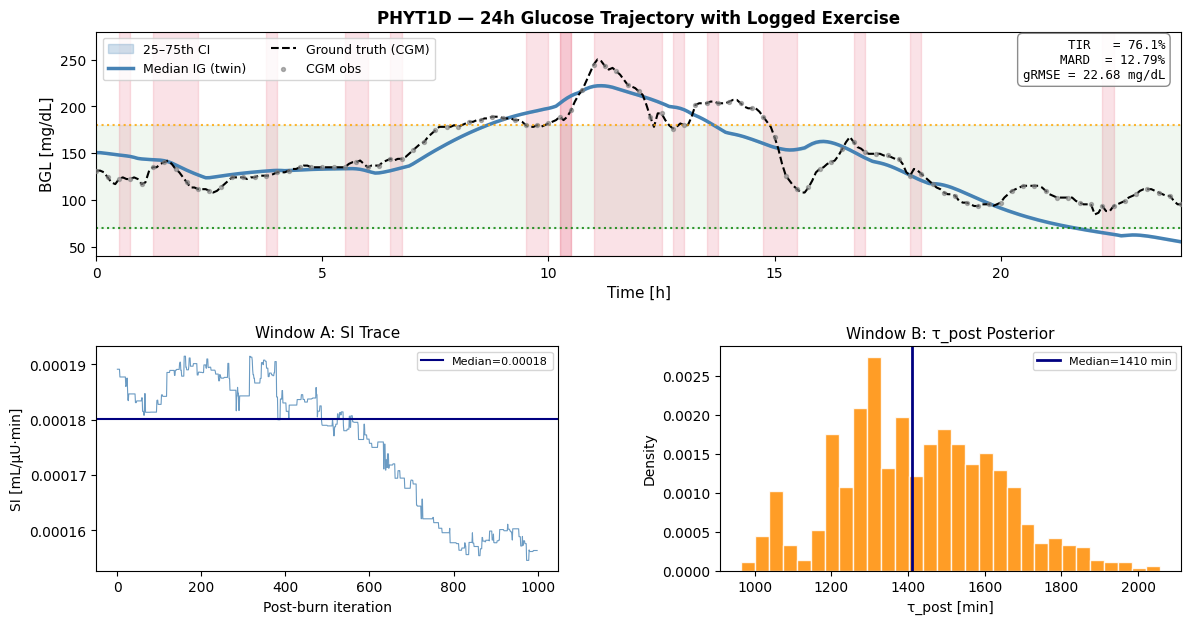


✓ 24h trajectory saved (with 15 exercise sessions).
  MARD=12.79%  gRMSE=22.68 mg/dL
  TIR=76.1%  TBR=0.0%  TAR=23.9%


In [23]:
fig = plt.figure(figsize=(14, 7))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.40, wspace=0.35)
# ── Main 24h trajectory ───────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.fill_between(times_h, IG_25, IG_75,
                 alpha=0.25, color="steelblue", label="25–75th CI")
ax1.plot(times_h, IG_50,  color="steelblue", lw=2.5, label="Median IG (twin)")
ax1.plot(times_h, ig_true, color="black", lw=1.5, ls="--", label="Ground truth (CGM)")
ax1.scatter(times_true[::3]/60, cgm_obs[::3],
            s=8, color="grey", alpha=0.6, zorder=4, label="CGM obs")
ax1.axhline(70,  color="green",  ls=":", lw=1.5, alpha=0.8)
ax1.axhline(180, color="orange", ls=":", lw=1.5, alpha=0.8)
ax1.fill_between(times_h, 70, 180, alpha=0.06, color="green")

# ── Shade exercise sessions ───────────────────────────────────────────────────
for s in USER_PARAMS.get("exercise_sessions", []):
    ax1.axvspan(s["t_start"]/60, (s["t_start"]+s["d"])/60,
                color="crimson", alpha=0.12, zorder=1)
# Add a single legend handle for the exercise band
if USER_PARAMS.get("exercise_sessions"):
    import matplotlib.patches as mpatches
    ex_patch = mpatches.Patch(color="crimson", alpha=0.25,
                              label="Exercise bout")
    handles, labels = ax1.get_legend_handles_labels()
    handles.append(ex_patch); labels.append("Exercise bout")
    ax1.legend(handles, labels, fontsize=9, loc="upper left", ncol=2)

ax1.set_xlim(0, 24); ax1.set_ylim(40, 280)
ax1.set_xlabel("Time [h]", fontsize=11)
ax1.set_ylabel("BGL [mg/dL]", fontsize=11)
ax1.set_title("PHYT1D — 24h Glucose Trajectory with Logged Exercise",
              fontsize=12, fontweight="bold")
ax1.legend(fontsize=9, loc="upper left", ncol=2)

# ── Metrics box in top-right corner ───────────────────────────────────────────
metrics_text = (f"TIR   = {metrics['TIR']:.1f}%\n"
                f"MARD  = {metrics['MARD']:.2f}%\n"
                f"gRMSE = {metrics['gRMSE']:.2f} mg/dL")
ax1.text(0.985, 0.97, metrics_text,
         transform=ax1.transAxes,
         fontsize=9, fontfamily="monospace",
         verticalalignment="top", horizontalalignment="right",
         bbox=dict(boxstyle="round,pad=0.4",
                   facecolor="white", edgecolor="grey", alpha=0.9))

# ── SI trace ──────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
si_samples = [s["SI"] for s in chain_A]
ax2.plot(si_samples, color="steelblue", lw=0.8, alpha=0.8)
ax2.axhline(np.median(si_samples), color="navy", ls="-", lw=1.5,
            label=f"Median={np.median(si_samples):.5f}")
ax2.set_title("Window A: SI Trace", fontsize=11)
ax2.set_xlabel("Post-burn iteration"); ax2.set_ylabel("SI [mL/μU·min]")
ax2.legend(fontsize=8)
# ── tau_post posterior ────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
tp_samples = [s["tau_post"] for s in chain_B]
ax3.hist(tp_samples, bins=30, color="darkorange",
         edgecolor="white", alpha=0.85, density=True)
ax3.axvline(np.median(tp_samples), color="navy", ls="-", lw=2,
            label=f"Median={np.median(tp_samples):.0f} min")
ax3.set_title("Window B: τ_post Posterior", fontsize=11)
ax3.set_xlabel("τ_post [min]"); ax3.set_ylabel("Density")
ax3.legend(fontsize=8)
plt.savefig(r"C:\MY_PROJECTS\Exe_aware_DT\Results\Adult10.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\n✓ 24h trajectory saved (with {len(USER_PARAMS.get('exercise_sessions', []))} exercise sessions).")
print(f"  MARD={metrics['MARD']:.2f}%  gRMSE={metrics['gRMSE']:.2f} mg/dL")
print(f"  TIR={metrics['TIR']:.1f}%  TBR={metrics['TBR']:.1f}%  TAR={metrics['TAR']:.1f}%")